In [1]:
# ==============================================
# K-Means Clustering on California Housing Data
# ==============================================

# Import necessary libraries
# These are external packages that add special functionality to Python.
import pandas as pd                # For working with data in table (DataFrame) format
import numpy as np                 # For numerical operations
from sklearn.preprocessing import StandardScaler  # To normalize numeric data
from sklearn.cluster import KMeans  # The main K-Means algorithm
import matplotlib.pyplot as plt     # For data visualization
from google.colab import files      # For uploading/downloading files in Google Colab


In [16]:
# ----------------------------------------------
# Upload the CSV file
# ----------------------------------------------
print("Please upload your californiahousing.csv file")
uploaded = files.upload()  # Opens a file upload dialog box in Google Colab

# Read the uploaded CSV into a pandas DataFrame
data = pd.read_csv('californiahousing.csv')

# Display the first 20 rows to check the data
print("\nData successfully loaded! Here's what it looks like:")
display(data.head(20))


Please upload your californiahousing.csv file


Saving californiahousing.csv to californiahousing (1).csv

Data successfully loaded! Here's what it looks like:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY
5,-122.25,37.85,52,919,213.0,413,193,4.0368,269700,NEAR BAY
6,-122.25,37.84,52,2535,489.0,1094,514,3.6591,299200,NEAR BAY
7,-122.25,37.84,52,3104,687.0,1157,647,3.1200,241400,NEAR BAY
8,-122.26,37.84,42,2555,665.0,1206,595,2.0804,226700,NEAR BAY
9,-122.25,37.84,52,3549,707.0,1551,714,3.6912,261100,NEAR BAY


In [17]:
# Convert text (categorical) column 'ocean_proximity' into numeric dummy variables
data_encoded = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)

# Ensure all boolean (True/False) columns are stored as integers (1 or 0)
dummy_cols = data_encoded.columns[data_encoded.dtypes == 'bool']
data_encoded[dummy_cols] = data_encoded[dummy_cols].astype(int)


In [18]:
# ----------------------------------------------
# Count missing values
# ----------------------------------------------
print("\nChecking for missing values...")
print(data_encoded.isnull().sum())  # Checks how many missing (NaN) values are in each column



Checking for missing values...
longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
median_house_value              0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,0,0,1,0
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,0,0,1,0
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,0,0,1,0
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,0,0,1,0
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,0,0,1,0


In [29]:
# Replace missing numeric values with the column mean
data_encoded = data_encoded.fillna(data_encoded.mean())
print("Missing values handled (filled with column means).")

Missing values handled (filled with column means).


In [30]:
# ----------------------------------------------
# Count missing values
# ----------------------------------------------
print("\nChecking for missing values...")
print(data_encoded.isnull().sum())  # Checks how many missing (NaN) values are in each column


Checking for missing values...
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


In [31]:
# ----------------------------------------------
# Standardize numeric columns
# ----------------------------------------------
# Standardization makes sure all numeric values have mean = 0 and std = 1
scaler = StandardScaler()
numeric_cols = data_encoded.columns  # Select all numeric columns
data_scaled = scaler.fit_transform(data_encoded)  # Apply scaling
data_scaled_df = pd.DataFrame(data_scaled, columns=numeric_cols)  # Convert back to DataFrame

data_scaled_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.975228,-0.974429,-0.977033,2.344766,2.129631,-0.681889,-0.015566,2.830742,-0.384466
1,-1.322844,1.043185,-0.607019,2.045890,1.355088,0.861439,1.669961,2.332238,1.314156,-0.681889,-0.015566,2.830742,-0.384466
2,-1.332827,1.038503,1.856182,-0.535746,-0.829732,-0.820777,-0.843637,1.782699,1.258693,-0.681889,-0.015566,2.830742,-0.384466
3,-1.337818,1.038503,1.856182,-0.624215,-0.722399,-0.766028,-0.733781,0.932968,1.165100,-0.681889,-0.015566,2.830742,-0.384466
4,-1.337818,1.038503,1.856182,-0.462404,-0.615066,-0.759847,-0.629157,-0.012881,1.172900,-0.681889,-0.015566,2.830742,-0.384466


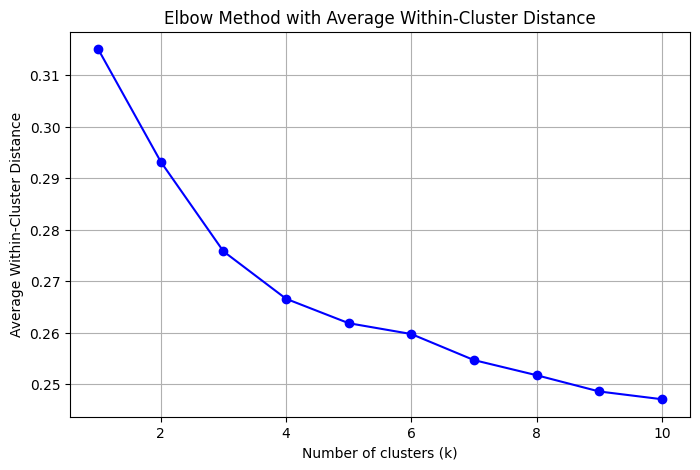

In [32]:
# ----------------------------------------------
# Step 6: Find the optimal number of clusters (Elbow Method)
# ----------------------------------------------
from sklearn.metrics import pairwise_distances  # To compute distances between data points and cluster centers

avg_within_distances = []  # List to store average distance within clusters
k_values = range(1, 11)    # Try cluster numbers (k) from 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)  # Create KMeans model with k clusters
    kmeans.fit(data_scaled_df)  # Create model on the encoded data

    # Calculate distance between each data point and its cluster center
    distances = pairwise_distances(data_scaled_df, kmeans.cluster_centers_[kmeans.labels_])
    #scikit-learn stores the learned attributes as variables ending with an underscore (_)

    # Find the average distance across all clusters
    avg_distance = np.mean(distances)

    # Use reciprocal to make elbow plot slope upward
    avg_within_distances.append(1 / avg_distance)

# Plot the Elbow Curve to help find optimal number of clusters visually
plt.figure(figsize=(8, 5))
plt.plot(k_values, avg_within_distances, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Within-Cluster Distance')
plt.title('Elbow Method with Average Within-Cluster Distance')
plt.grid(True)
plt.show()


In [37]:
# ----------------------------------------------
# Step 7: Choose optimal k (you can pick from the elbow plot)
# ----------------------------------------------
# User inputs their chosen number of clusters
optimal_k = int(input("Enter the optimal number of clusters (from the plot): "))

# Create and train final KMeans model using chosen number of clusters
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_final.fit(data_scaled_df)

Enter the optimal number of clusters (from the plot): 4


KMeans(n_clusters=4, random_state=42)

In [38]:
# ----------------------------------------------
#
# Evaluate model using silhouette score (ranges between –1 and +1, high values represent good clustering)
# ----------------------------------------------
from sklearn.metrics import silhouette_score  # Silhouette Score measures clustering quality

# Calculate silhouette score for both training and test sets
silhouette = silhouette_score(data_scaled_df, kmeans_final.labels_)

print("\nModel Evaluation Metrics:")
print(f"Silhouette Score: {silhouette:.3f}")



Model Evaluation Metrics:
Silhouette Score: 0.255


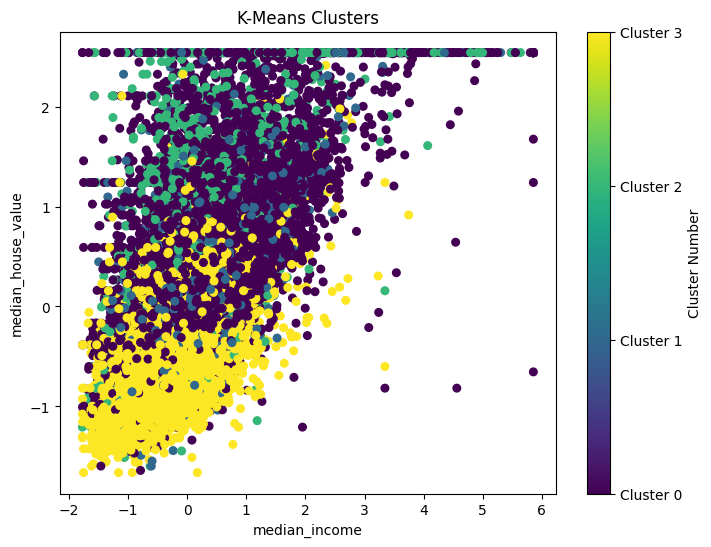

In [39]:
# ----------------------------------------------
# Visualize clusters
# ----------------------------------------------
clusters = kmeans_final.predict(data_scaled_df)  # Predict clusters
plt.figure(figsize=(8,6))

# Plot two selected features for visualization (feature 7 vs feature 8)
scatter = plt.scatter(data_scaled_df.iloc[:, 7], data_scaled_df.iloc[:, 8], c=clusters, cmap='viridis', s=30)
plt.xlabel(data_scaled_df.columns[7])
plt.ylabel(data_scaled_df.columns[8])
plt.title('K-Means Clusters')

# Add color legend for clusters
cbar = plt.colorbar(scatter, ticks=np.unique(clusters))
cbar.set_label('Cluster Number')
cbar.set_ticks(np.unique(clusters))
cbar.set_ticklabels([f'Cluster {i}' for i in np.unique(clusters)])
plt.show()

Cluster 0: Average Distance to Center = 2.4570
Cluster 1: Average Distance to Center = 3.6335
Cluster 2: Average Distance to Center = 2.0024
Cluster 3: Average Distance to Center = 2.1525


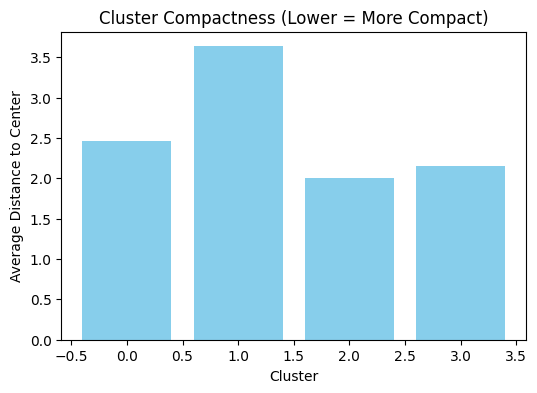

In [42]:
# ----------------------------------------------
# Step 12: Check Cluster Compactness
# ----------------------------------------------
from sklearn.metrics import pairwise_distances

# Add the cluster assignments to the DataFrame
data_scaled_df['Cluster'] = kmeans_final.labels_

# Calculate distance of every data point from all cluster centers
distances = pairwise_distances(data_scaled_df.drop('Cluster', axis=1), kmeans_final.cluster_centers_)

# Calculate average distance of points in each cluster to their center
compactness = []
for i in range(optimal_k):
    cluster_points = data_scaled_df['Cluster'] == i
    avg_distance = np.mean(distances[cluster_points, i])
    compactness.append(avg_distance)
    print(f"Cluster {i}: Average Distance to Center = {avg_distance:.4f}")

# Bar chart to show compactness of each cluster
plt.figure(figsize=(6,4))
plt.bar(range(optimal_k), compactness, color='skyblue')
plt.xlabel("Cluster")
plt.ylabel("Average Distance to Center")
plt.title("Cluster Compactness (Lower = More Compact)")
plt.show()

In [43]:
# ----------------------------------------------
# Step 11: Cluster Characterization
# ----------------------------------------------
# Summarize average feature values within each cluster
cluster_summary = data_scaled_df.groupby('Cluster').mean(numeric_only=True)
cluster_summary['Count'] = data_scaled_df['Cluster'].value_counts().sort_index().values
cluster_summary = cluster_summary.round(3)

print("\nCluster Characterization (Mean values per cluster):")
display(cluster_summary)

# Save the summary to CSV
cluster_summary.to_csv('cluster_characterization.csv')
files.download('cluster_characterization.csv')
print("\nCluster characterization saved as 'cluster_characterization.csv'.")



Cluster Characterization (Mean values per cluster):


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,Count
Cluster,,,,,,,,,,,,,,
0,0.451,-0.616,0.148,-0.190,-0.188,-0.137,-0.170,0.214,0.361,-0.628,0.015,-0.353,0.300,10436
1,0.245,-0.207,-0.980,2.459,2.520,2.354,2.520,0.161,0.085,0.106,-0.016,-0.187,-0.106,1552
2,-1.344,1.015,0.773,-0.172,-0.166,-0.272,-0.147,0.151,0.455,-0.682,-0.016,2.831,-0.384,2209
3,-0.328,0.699,-0.268,-0.226,-0.246,-0.252,-0.281,-0.437,-0.761,1.225,-0.016,-0.353,-0.328,6443


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Cluster characterization saved as 'cluster_characterization.csv'.
